In [2]:
# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np

# Step 1: Define portfolio stocks
tickers = ["AAPL", "JNJ", "XOM", "BTC-USD"]

# Step 2: Download stock price data
data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Step 3: Extract closing prices
prices = data["Close"]

# Step 4: Calculate daily returns
returns = prices.pct_change().dropna()

# Step 5: Define portfolio weights
weights = np.array([0.25, 0.25, 0.25, 0.25])

# Step 6: Calculate portfolio returns
portfolio_returns = returns.dot(weights)

# Step 7: Calculate portfolio growth
portfolio_value = (1 + portfolio_returns).cumprod()

# Step 8: Create portfolio dataframe
portfolio_df = pd.DataFrame({
    "Date": portfolio_returns.index,
    "Portfolio_Return": portfolio_returns,
    "Portfolio_Value": portfolio_value
})

# Step 9: Export CSV files for Tableau
prices.to_csv("stock_prices.csv")
returns.to_csv("stock_returns.csv")
portfolio_df.to_csv("portfolio_summary.csv", index=False)

print("CSV files created successfully!")

[*********************100%***********************]  4 of 4 completed


CSV files created successfully!


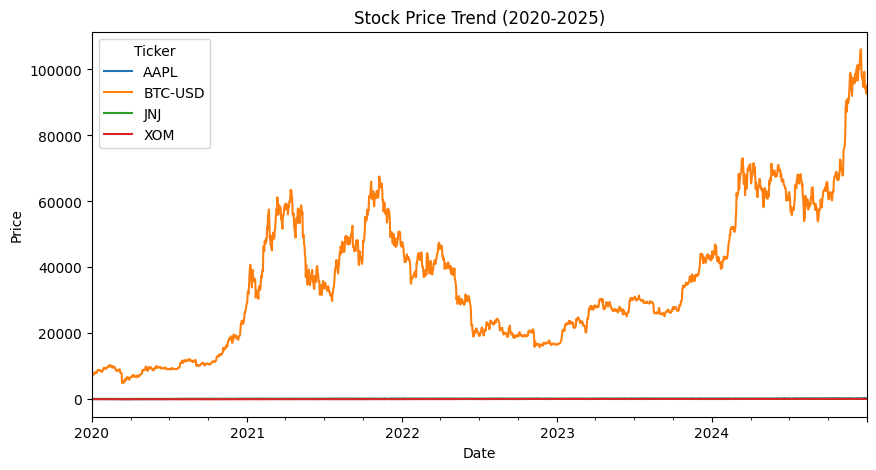

In [6]:



import matplotlib.pyplot as plt

prices.plot(figsize=(10,5))
plt.title("Stock Price Trend (2020-2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

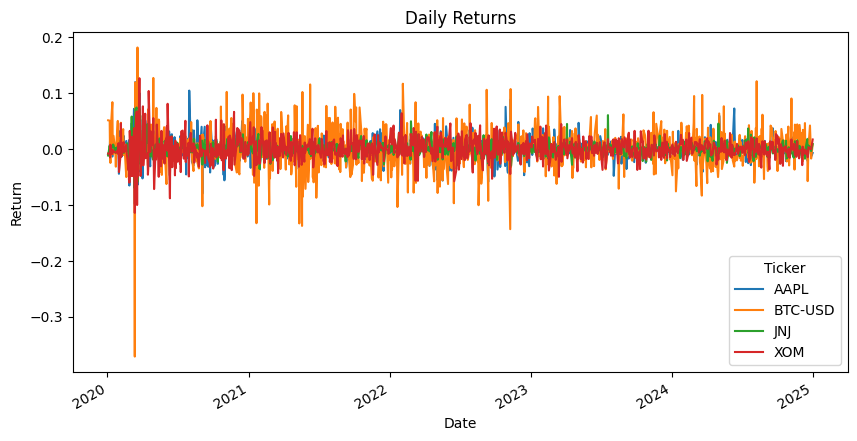

In [7]:
returns.plot(figsize=(10,5))
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

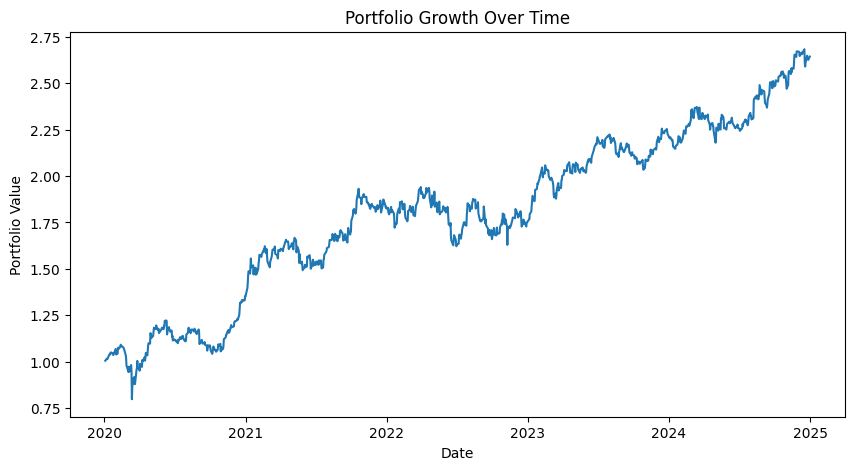

In [8]:
plt.figure(figsize=(10,5))
plt.plot(portfolio_df["Date"], portfolio_df["Portfolio_Value"])
plt.title("Portfolio Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.show()

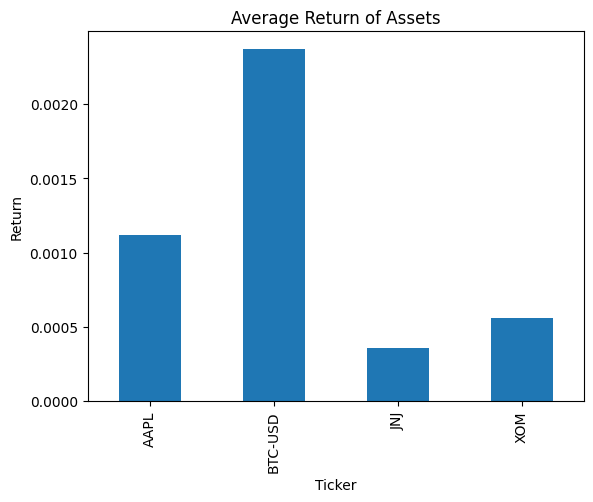

In [9]:
returns.mean().plot(kind="bar")
plt.title("Average Return of Assets")
plt.ylabel("Return")
plt.show()